# Machine Learning — Prediction retard de livraison

## 1. Chargement des donnees

In [7]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

BASE = r'c:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\\'

def read_csv_auto(filepath):
    for encoding in ['utf-8', 'latin-1', 'cp1252']:
        for sep in [',', ';', '\t']:
            try:
                df = pd.read_csv(filepath, sep=sep, encoding=encoding, low_memory=False)
                if df.shape[1] > 1:
                    return df
            except Exception:
                continue
    raise ValueError(f'Impossible de lire {filepath}')

df_liv = read_csv_auto(BASE + 'Extraction livraison client 2021-2025.csv')
df_cmd = read_csv_auto(BASE + 'Extraction commande client 2021-2025.csv')

print('Livraison :', df_liv.shape)
print('Commande  :', df_cmd.shape)
print('\nColonnes Livraison:', df_liv.columns.tolist())
print('Colonnes Commande :', df_cmd.columns.tolist())

Livraison : (353325, 13)
Commande  : (352549, 14)

Colonnes Livraison: ['#', 'Num commande', "Numéro d'article", 'Qté', 'Date de livraison réelle', 'Code client/fournisseur', 'Activité stratégique client', 'Activité stratégique article', 'Ségment stratégique', 'Type activité', 'Pays/région', 'Prix de vente', 'Devise du prix']
Colonnes Commande : ['#', 'Num commande', "Numéro d'article", 'Quantité', "Date d'enregistrement", 'Date de livraison demandée', 'Code client/fournisseur', 'Activité stratégique client', 'Activité stratégique article', 'Ségment stratégique', 'Type activité', 'Pays/région', 'Prix de vente', 'Devise du prix']


## 2. Merge sur Num commande + Numero d'article

In [24]:
# fait par moi 

dfm = pd.merge(
    df_cmd,
    df_liv,
    on=["Num commande", "Numéro d'article"],
    how='left'
)
pd.set_option('display.max_columns', None)
dfm.shape
dfm.head()


,#_x,Num commande,Numéro d'article,Qte_commandee,Date d'enregistrement,Date de livraison demandée,Code client/fournisseur_x,Activité stratégique client_x,Activité stratégique article_x,Ségment stratégique_x,Type activité_x,Pays/région_x,Prix de vente_x,Devise du prix_x,#_y,Qté,Date de livraison réelle,Code client/fournisseur_y,Activité stratégique client_y,Activité stratégique article_y,Ségment stratégique_y,Type activité_y,Pays/région_y,Prix de vente_y,Devise du prix_y
0,1,142660,A0276,300,23/09/2020,15/01/2021,C10379,ELEVAGE,ELEVAGE,ECORNAGE,Outil GAZ,IE,89.00,EUR,3982.0,82.0,15/01/2021,C10379,ELEVAGE,ELEVAGE,ECORNAGE,Outil GAZ,IE,89.00,EUR
1,1,142660,A0276,300,23/09/2020,15/01/2021,C10379,ELEVAGE,ELEVAGE,ECORNAGE,Outil GAZ,IE,89.00,EUR,12170.0,218.0,17/02/2021,C10379,ELEVAGE,ELEVAGE,ECORNAGE,Outil GAZ,IE,89.00,EUR
2,2,143298,A1577,2,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,9.04,EUR,1.0,2.0,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,9.04,EUR
3,3,143298,A1571,1,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,OUTIL CHAUFFANT,PIECES DETACHEES,FR,11.45,EUR,2.0,1.0,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,OUTIL CHAUFFANT,PIECES DETACHEES,FR,11.45,EUR
4,4,143298,A1283,1,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,17.19,EUR,3.0,1.0,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,17.19,EUR


In [28]:
# Detecte les noms exacts des colonnes cles
col_num_cmd  = [c for c in df_liv.columns if 'num' in c.lower() and 'commande' in c.lower()][0]
col_article  = [c for c in df_liv.columns if 'article' in c.lower()][0]
col_qte_liv  = [c for c in df_liv.columns if 'qt' in c.lower()][0]
col_date_liv = [c for c in df_liv.columns if 'date' in c.lower()][0]
col_qte_cmd  = [c for c in df_cmd.columns if 'quantit' in c.lower() or ('qt' in c.lower() and c not in df_liv.columns)][0]

print('Cles de jointure      :', col_num_cmd, '|', col_article)
print('Qte livraison         :', col_qte_liv)
print('Date livraison reelle :', col_date_liv)
print('Qte commande          :', col_qte_cmd)

# Selectionne et renomme les colonnes de livraison pour eviter conflits
df_liv_sel = df_liv[[col_num_cmd, col_article, col_qte_liv, col_date_liv]].rename(columns={
# df_liv_sel = df_liv.rename(columns={

    col_qte_liv:  'Qte_livree',
    col_date_liv: 'Date_livraison_reelle'
})
df_cmd = df_cmd.rename(columns={col_qte_cmd: 'Qte_commandee'})

# Merge gauche : toutes les commandes, avec ou sans livraison correspondante
df = pd.merge(
    df_cmd,
    df_liv_sel,
    on=[col_num_cmd, col_article],
    how='left'
)

print(f'\nApres merge : {df.shape}')
print(f'Commandes sans livraison : {df["Date_livraison_reelle"].isna().sum():,}')
df.head() 

Cles de jointure      : Num commande | Numéro d'article
Qte livraison         : Qté
Date livraison reelle : Date de livraison réelle
Qte commande          : Qte_commandee

Apres merge : (361671, 16)
Commandes sans livraison : 333


,#,Num commande,Numéro d'article,Qte_commandee,Date d'enregistrement,Date de livraison demandée,Code client/fournisseur,Activité stratégique client,Activité stratégique article,Ségment stratégique,Type activité,Pays/région,Prix de vente,Devise du prix,Qte_livree,Date_livraison_reelle
0,1,142660,A0276,300,23/09/2020,15/01/2021,C10379,ELEVAGE,ELEVAGE,ECORNAGE,Outil GAZ,IE,89.00,EUR,82.0,15/01/2021
1,1,142660,A0276,300,23/09/2020,15/01/2021,C10379,ELEVAGE,ELEVAGE,ECORNAGE,Outil GAZ,IE,89.00,EUR,218.0,17/02/2021
2,2,143298,A1577,2,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,9.04,EUR,2.0,04/01/2021
3,3,143298,A1571,1,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,OUTIL CHAUFFANT,PIECES DETACHEES,FR,11.45,EUR,1.0,04/01/2021
4,4,143298,A1283,1,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,17.19,EUR,1.0,04/01/2021


## 3. Conversion des dates & calcul du retard

In [9]:
col_date_demandee = [c for c in df.columns if 'demand' in c.lower()][0]
col_date_enreg    = [c for c in df.columns if 'enregistrement' in c.lower()][0]

for col in [col_date_demandee, col_date_enreg, 'Date_livraison_reelle']:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Retard = date livraison reelle - date demandee (jours)
df['retard_jours'] = (df['Date_livraison_reelle'] - df[col_date_demandee]).dt.days
df['en_retard']    = (df['retard_jours'] > 0).astype(int)

# Garde uniquement les commandes livrees
df_livrees = df.dropna(subset=['Date_livraison_reelle', col_date_demandee]).copy()

print(f'Commandes livrees : {len(df_livrees):,}')
print(f'Taux de retard    : {df_livrees["en_retard"].mean()*100:.1f}%')
df_livrees[['retard_jours', 'en_retard']].describe()

Commandes livrees : 361,338
Taux de retard    : 19.3%


,retard_jours,en_retard
count,361338.000000,361338.000000
mean,0.997114,0.193071
std,4.994920,0.394709
min,-124.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,139.000000,1.000000


## 4. Feature engineering

In [10]:
df_livrees['mois_commande'] = df_livrees[col_date_enreg].dt.month
df_livrees['trimestre']     = df_livrees[col_date_enreg].dt.quarter
df_livrees['annee']         = df_livrees[col_date_enreg].dt.year
df_livrees['delai_prevu']   = (df_livrees[col_date_demandee] - df_livrees[col_date_enreg]).dt.days

print('Features temporelles creees.')
df_livrees[['mois_commande', 'trimestre', 'annee', 'delai_prevu']].head()

Features temporelles creees.


,mois_commande,trimestre,annee,delai_prevu
0,9,3,2020,114
1,9,3,2020,114
2,10,4,2020,88
3,10,4,2020,88
4,10,4,2020,88


## 5. Preparation pour le Machine Learning

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Colonnes categoriques pertinentes
cat_cols = [c for c in df_livrees.columns
            if df_livrees[c].dtype == 'object'
            and c not in [col_num_cmd, col_article, 'Devise du prix', '#']
            and 'date' not in c.lower()]

num_cols = ['Qte_commandee', 'Qte_livree', 'Prix de vente',
            'mois_commande', 'trimestre', 'annee', 'delai_prevu']
num_cols = [c for c in num_cols if c in df_livrees.columns]

features = cat_cols + num_cols
print('Features :', features)

df_ml = df_livrees[features + ['en_retard']].copy()

le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

df_ml = df_ml.dropna()
print(f'Dataset final : {df_ml.shape}')

Features : ['Qte_commandee', 'Qte_livree', 'Prix de vente', 'mois_commande', 'trimestre', 'annee', 'delai_prevu']
Dataset final : (361338, 8)


In [13]:
X = df_ml[features]
y = df_ml['en_retard']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Retards train : {y_train.mean()*100:.1f}% | test : {y_test.mean()*100:.1f}%')

Train : (289070, 7) | Test : (72268, 7)
Retards train : 19.3% | test : 19.3%


## 6. Modele Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['A temps', 'En retard']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba):.3f}')

              precision    recall  f1-score   support

     A temps       0.86      0.91      0.88     58315
   En retard       0.51      0.39      0.44     13953

    accuracy                           0.81     72268
   macro avg       0.68      0.65      0.66     72268
weighted avg       0.79      0.81      0.80     72268

AUC-ROC : 0.767


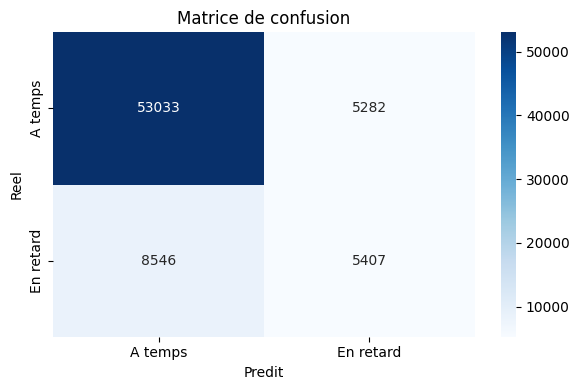

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A temps', 'En retard'],
            yticklabels=['A temps', 'En retard'])
plt.title('Matrice de confusion')
plt.ylabel('Reel'); plt.xlabel('Predit')
plt.tight_layout(); plt.show()

## 7. Importance des features

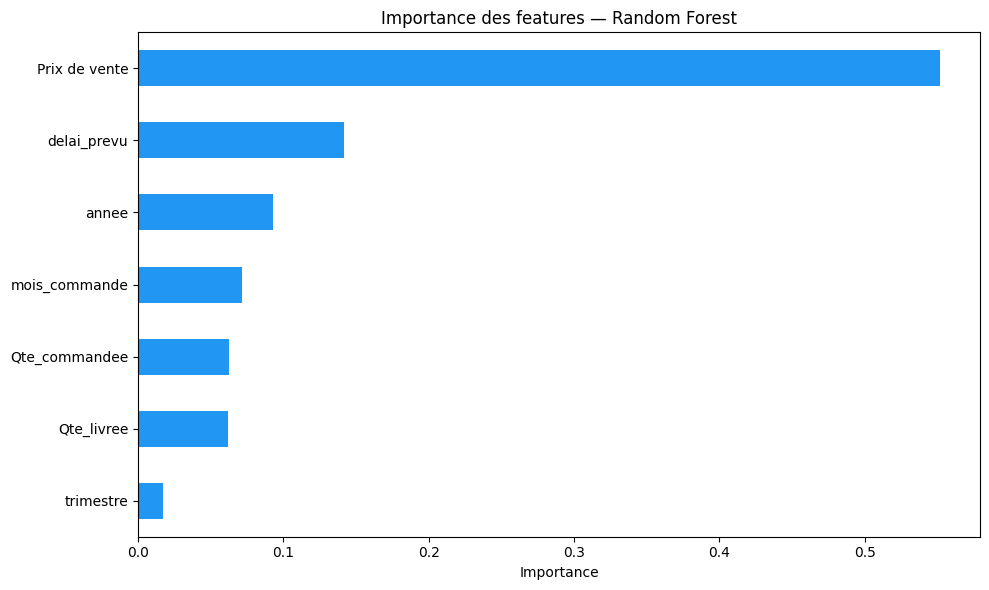

Prix de vente    0.551843
delai_prevu      0.141718
annee            0.092788
mois_commande    0.071664
Qte_commandee    0.062461
Qte_livree       0.062252
trimestre        0.017273


In [16]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#2196F3')
plt.title('Importance des features — Random Forest')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

print(importances.sort_values(ascending=False).to_string())